In [8]:
from pandas_datareader import data
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import urllib.request, json
import os
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

In [26]:
apiKey = "WQWW8HTP6PMNE20A"
ticker = "AAPL"

urlString = "https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=%s&outputsize=full&apikey=%s"%(ticker,apiKey)

file_to_save = "stock_market_data-%s.csv"%ticker
# print(file_to_save)

if not os.path.exists(file_to_save):
    with  urllib.request.urlopen(urlString) as url:
        data = json.loads(url.read().decode())

        # extract stok marrket data
        data = data['Time Series (Daily)']
        df = pd.DataFrame(columns= ['Date', 'Low','High', 'Close', "Open"])

        for i,j in data.items():
            # print(f"i : {i}")
            # print(f"j : {j}")

            date = dt.datetime.strptime(i, '%Y-%m-%d')
            data_row = [date.date(), float(j['3. low']),float(j['2. high']),
                        float(j['4. close']),float(j['1. open'])]
            
            df.loc[-1,:] = data_row
            df.index = df.index + 1
    
    print("Data saved to : %s"%file_to_save)
    df.to_csv(file_to_save)
else : 
    print('File already exists. Loading data from CSV')
    df = pd.read_csv(file_to_save)

File already exists. Loading data from CSV


In [27]:
df.head()

,Unnamed: 0,Date,Low,High,Close,Open
0,6399,2025-04-10,183.0000,194.7799,190.42,189.065
1,6398,2025-04-09,171.8900,200.6100,198.85,171.950
2,6397,2025-04-08,169.2101,190.3350,172.42,186.700
3,6396,2025-04-07,174.6200,194.1500,181.46,177.200
4,6395,2025-04-04,187.3400,199.8800,188.38,193.890


In [28]:
df = df.sort_values("Date")

In [29]:
df.head()

,Unnamed: 0,Date,Low,High,Close,Open
6399,0,1999-11-01,77.37,80.69,77.62,80.00
6398,1,1999-11-02,77.31,81.69,80.25,78.00
6397,2,1999-11-03,81.00,83.25,81.50,81.62
6396,3,1999-11-04,80.62,85.37,83.62,82.06
6395,4,1999-11-05,84.00,88.37,88.31,84.62


In [31]:
df.drop(columns="Unnamed: 0", inplace= True)
df.head()

,Date,Low,High,Close,Open
6399,1999-11-01,77.37,80.69,77.62,80.00
6398,1999-11-02,77.31,81.69,80.25,78.00
6397,1999-11-03,81.00,83.25,81.50,81.62
6396,1999-11-04,80.62,85.37,83.62,82.06
6395,1999-11-05,84.00,88.37,88.31,84.62


In [ ]:
df.reset_index(inplace= True)
df.head()

,index,Date,Low,High,Close,Open
0,6399,1999-11-01,77.37,80.69,77.62,80.00
1,6398,1999-11-02,77.31,81.69,80.25,78.00
2,6397,1999-11-03,81.00,83.25,81.50,81.62
3,6396,1999-11-04,80.62,85.37,83.62,82.06
4,6395,1999-11-05,84.00,88.37,88.31,84.62


In [33]:
df.drop(columns="index", inplace= True)
df.head()

,Date,Low,High,Close,Open
0,1999-11-01,77.37,80.69,77.62,80.00
1,1999-11-02,77.31,81.69,80.25,78.00
2,1999-11-03,81.00,83.25,81.50,81.62
3,1999-11-04,80.62,85.37,83.62,82.06
4,1999-11-05,84.00,88.37,88.31,84.62


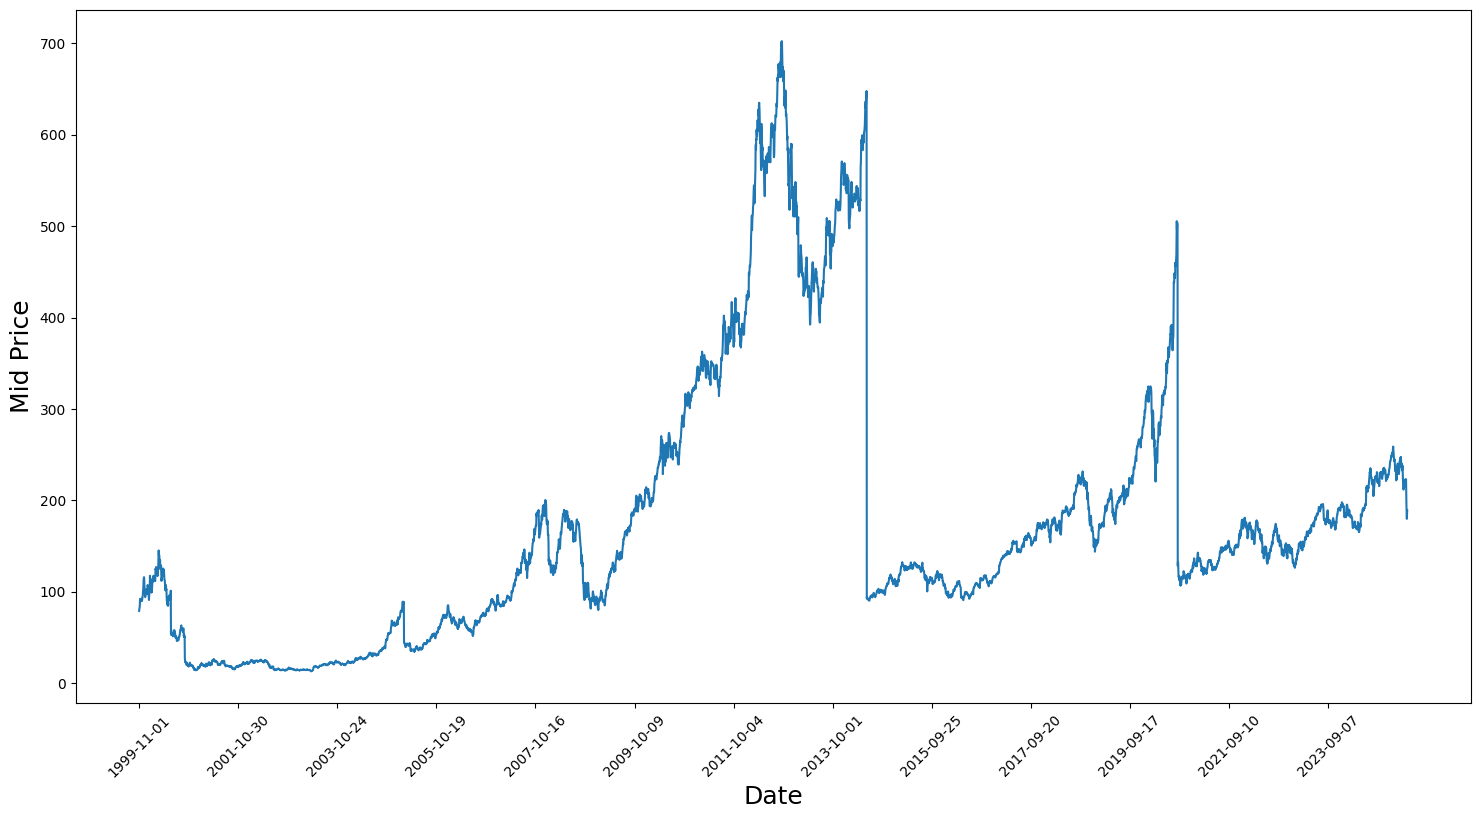

In [34]:
plt.figure(figsize=(18,9))
plt.plot(range(df.shape[0]), (df['Low']+df['High'])/2.0)
plt.xticks(range(0,df.shape[0],500),df['Date'].loc[::500],rotation=45)
plt.xlabel('Date',fontsize=18)
plt.ylabel('Mid Price',fontsize=18)
plt.show()